# World Map

/tmp/ipykernel_27057/3418139326.py:53: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


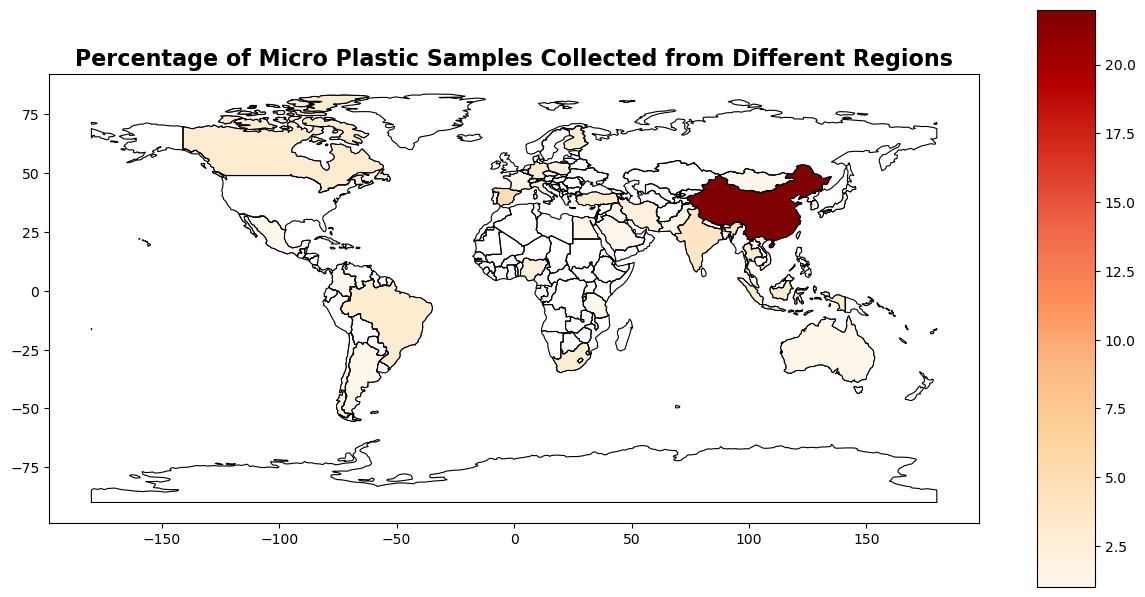

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Data for country percentages
country_percentage = {
    "China": 22,
    "Saudi Arabia": 1,
    "USA": 8,
    "Nigeria": 2,
    "Canada": 3,
    "Argentina": 1,
    "Indonesia": 3,
    "Portugal": 1,
    "Vietnam": 3,
    "Taiwan": 1,
    "Nederlands": 3,
    "South Korea": 1,
    "Italy": 2,
    "India": 4,
    "Australia": 1,
    "Tanzania": 1,
    "Brazil": 3,
    "Thailand": 3,
    "Denmark": 2,
    "Hungary": 2,
    "Colombia": 1,
    "Pakistan": 1,
    "Finland": 3,
    "Mongolia": 1,
    "Spain": 5,
    "Bangladesh": 1,
    "Nepal": 1,
    "UK": 2,
    "South Africa": 3,
    "Switzerland": 1,
    "Japan": 1,
    "France": 1,
    "Germany": 3,
    "Hong Kong": 2,
    "Iran": 2,
    "Iraq": 1,
    "Chile": 1,
    "Mexico": 1,
    "Malaysia": 1,
    "Turkey": 3,
    "Lebanon": 1,
    "Egypt": 1,
    "Poland": 2
}

# Load world shapefile
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Map percentage data to the world GeoDataFrame
world['Percentage'] = world['name'].map(country_percentage)

# Plot the world map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set the sea color
# ax.set_facecolor('lightblue')

# Plot only regions with data
world_with_data = world.dropna(subset=['Percentage'])
heatmap = world_with_data.plot(
    column='Percentage',
    cmap='OrRd',  # Use the crest colormap
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend_kwds={'shrink': 0.75, 'aspect': 10}
)

# Plot country boundaries for all regions (to ensure borders are visible even for uncolored countries)
world.boundary.plot(ax=ax, linewidth=0.8, color='black')

# # Annotate country names
# for idx, row in world_with_data.iterrows():
#     centroid = row['geometry'].centroid
#     ax.text(
#         centroid.x, centroid.y, row['name'],
#         fontsize=8, ha='center', color='darkblue', weight='bold'
#     )

# Add a title
plt.title("Percentage of Micro Plastic Samples Collected from Different Regions", fontsize=16, fontweight='bold')

# Save the plot as a PNG file
plt.savefig('images/world_map.png', dpi=220)

# Show the map
plt.show()


In [2]:
# Read the text file
with open("keywords.txt", "r") as file:
    text = file.read()

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK punkt resources in this environment and working directory
nltk.download('punkt', download_dir='.')
nltk.download('punkt_tab', download_dir='.')
nltk.download('stopwords', download_dir='.')


# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

# Tokenize and preprocess
tokens = word_tokenize(text)
stop_words = set(stopwords.words('english'))
keywords = [word.lower() for word in tokens if word.isalnum() and word.lower() not in stop_words]

[nltk_data] Downloading package punkt to ....
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to ....
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to ....
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
from nltk.stem import WordNetLemmatizer
from collections import Counter
import nltk

# Download WordNet data for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize all keywords
lemmatized_keywords = [lemmatizer.lemmatize(word) for word in keywords]

# Count keyword frequencies
keyword_freq = Counter(lemmatized_keywords)
common_keywords = keyword_freq.most_common(50)  # Top 20 keywords
print("Top Keywords:", common_keywords)

[nltk_data] Downloading package wordnet to /home/abhowmik/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/abhowmik/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Top Keywords: [('microplastics', 26), ('pollution', 11), ('health', 10), ('human', 8), ('plastic', 8), ('microplastic', 8), ('aquatic', 7), ('water', 6), ('environmental', 6), ('marine', 5), ('treatment', 5), ('toxicity', 5), ('method', 4), ('effect', 4), ('organic', 4), ('impact', 4), ('drinking', 3), ('emerging', 3), ('detection', 3), ('environment', 3), ('mitigation', 3), ('source', 3), ('ecosystem', 3), ('food', 3), ('air', 2), ('fiber', 2), ('pollutant', 2), ('life', 2), ('cycle', 2), ('assessment', 2), ('factor', 2), ('waste', 2), ('strategy', 2), ('characterization', 2), ('wastewater', 2), ('sea', 2), ('plant', 2), ('technology', 2), ('gut', 2), ('microbiota', 2), ('migration', 2), ('persistent', 2), ('fate', 2), ('transport', 2), ('organism', 2), ('physiology', 2), ('analytical', 2), ('matter', 2), ('membrane', 2), ('freshwater', 2)]


In [5]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Split the text into individual abstracts if needed
# with open("abstracts.txt", "r") as file:
#     abstracts = file.readlines()

# # Apply TF-IDF
# vectorizer = TfidfVectorizer(max_features=50, stop_words='english')  # Top 50 terms
# tfidf_matrix = vectorizer.fit_transform(abstracts)
# keywords_tfidf = vectorizer.get_feature_names_out()
# print("TF-IDF Keywords:", keywords_tfidf)


In [6]:
# from rake_nltk import Rake

# rake = Rake()  # By default, uses NLTK's stopwords
# rake.extract_keywords_from_text(text)
# ranked_phrases = rake.get_ranked_phrases()  # Ranked keywords/phrases
# print("RAKE Keywords:", ranked_phrases[:20])  # Top 20 phrases


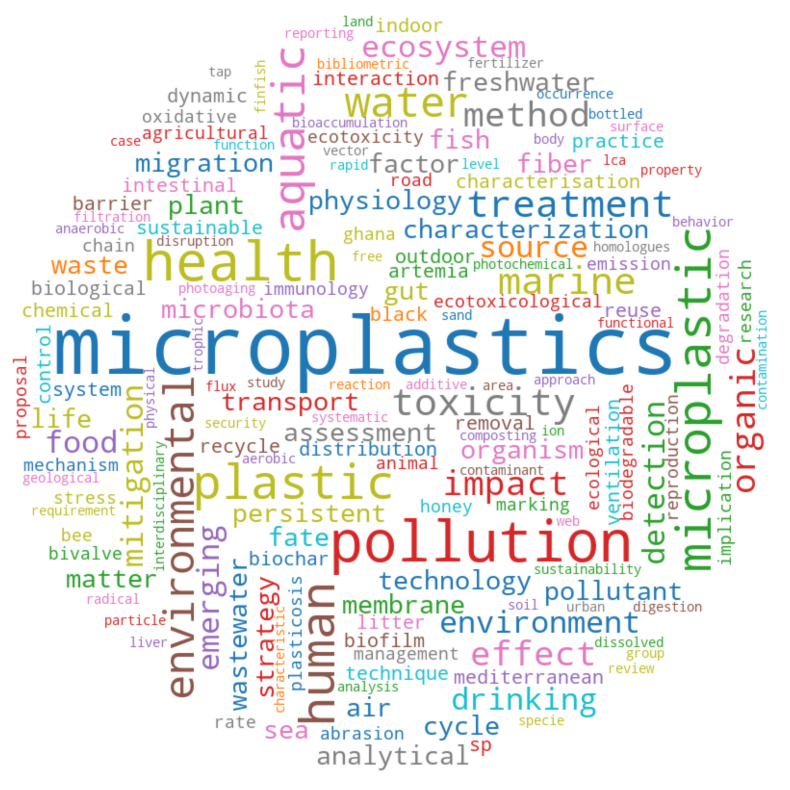

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# Create a circular mask
x, y = np.ogrid[:800, :800]
mask = (x - 400) ** 2 + (y - 400) ** 2 > 400 ** 2
mask = 255 * mask.astype(int)

wordcloud = WordCloud(
    width=800, height=800, background_color='white', mask=mask,
    colormap='tab10', contour_width=1, contour_color='white'
).generate_from_frequencies(keyword_freq)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='gaussian')
plt.axis('off')

# Save the word cloud as a PNG file
plt.savefig('images/wordcloud.png', dpi=220)

plt.show()


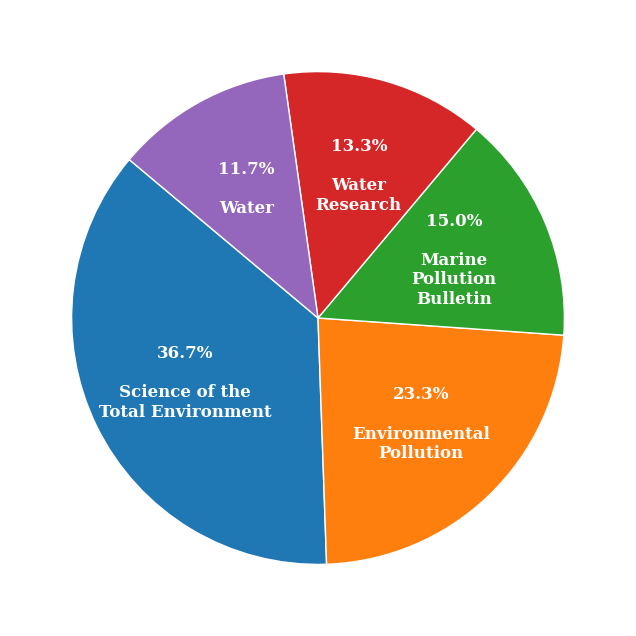

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from the image
journals = ["Science of the\nTotal Environment", "Environmental\nPollution", 
            "Marine\nPollution\nBulletin", "Water\nResearch", "Water"]
counts = [22, 14, 9, 8, 7]

# Prepare data in a pandas DataFrame
data = pd.DataFrame({
    'Journals': journals,
    'Counts': counts
})

# Create a pie chart
plt.figure(figsize=(8, 8))
sns.set(style="whitegrid")

# Plot the pie chart
wedges, texts, autotexts = plt.pie(
    data['Counts'], autopct=lambda pct: f"{pct:.1f}%",
    startangle=140, colors=sns.color_palette("tab10", n_colors=len(journals)),
)
for i, autotext in enumerate(autotexts):
    autotext.set_fontfamily('serif')
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_text(f"{autotext.get_text()}\n\n{journals[i]}")

# Add a legend
# plt.legend(wedges, data['Journals'], title="Journals", loc="best", bbox_to_anchor=(1, 0.5))
# plt.title("Top 5 Journals Contribution")
plt.show()


/tmp/ipykernel_27057/3108199882.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


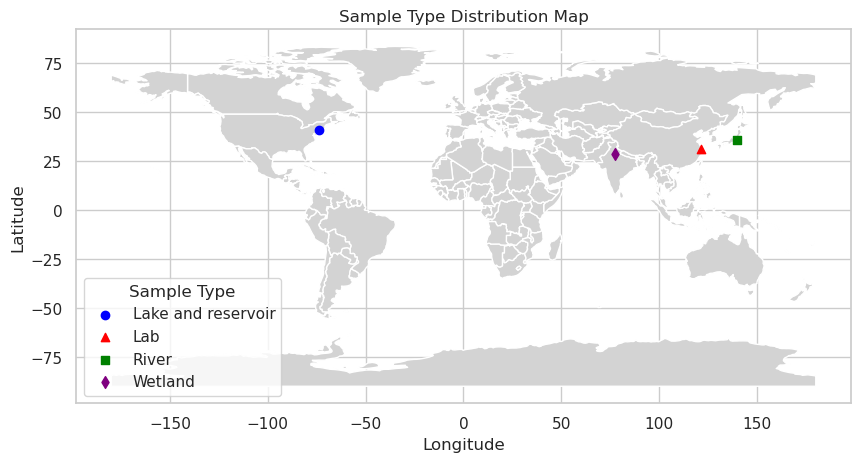

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Load the base map (Natural Earth shapefiles can be used)
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Sample data: Replace this with your data
data = pd.DataFrame({
    'Latitude': [40.7128, 31.2304, 35.6895, 28.6139],  # Example latitudes
    'Longitude': [-74.0060, 121.4737, 139.6917, 77.2090],  # Example longitudes
    'Sample Type': ['Lake and reservoir', 'Lab', 'River', 'Wetland']
})

# Convert DataFrame to GeoDataFrame
gdf = gpd.GeoDataFrame(
    data, geometry=gpd.points_from_xy(data.Longitude, data.Latitude))

# Plot the base map
fig, ax = plt.subplots(figsize=(10, 10))
world.plot(ax=ax, color='lightgrey')

# Plot points with different markers for sample types
sample_types = data['Sample Type'].unique()
colors = ['blue', 'red', 'green', 'purple', 'orange']  # Colors for different types
markers = ['o', '^', 's', 'd', 'p']  # Different markers for types

for i, sample_type in enumerate(sample_types):
    subset = gdf[gdf['Sample Type'] == sample_type]
    subset.plot(ax=ax, color=colors[i], marker=markers[i], label=sample_type)

# Add legend and labels
plt.legend(title="Sample Type", loc='lower left')
plt.title("Sample Type Distribution Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
